In [49]:
import pandas as pd

url = "/content/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [50]:
df = df.dropna(subset=['Class'])

Problema de classificação desbalanceada

fraudes são raras modelo pode ignorar coluna 1

Atributos de V1-V28 representam informações sensiveis sobre a empresa e clientes, então foram descaracterizadas.

Atributo Class indica se uma transação é fraudulenta 1 ou não é fraudulenta 0

Neste cenario é comum haver muitas transações corretas e poucas fraudes, por isso o desbalanceamento é preciso equipara-las para o modelo conseguir generalizar casos novos.

In [51]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


Feature Engineering

Variáveis que ajudam o modelo. São variáveis criadas para representar valores em escalas melhores para analise neste caso com uso de logaritimo para ampliar valores minimo acima de 0.

In [52]:
import numpy as np

df['Amount_log'] = np.log1p(df['Amount'])

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

In [54]:
from sklearn.model_selection import train_test_split

x = df.drop(['Class'], axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.2, random_state=42
)

Logistic Regression

In [55]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Warning: O modelo não terminou de treinar com as 1000 iterações, mas é possívevl continuar o processo. Para remover o warning é preciso aprimorar o modelo analisando parametros e realizando seleção dos melhores hiperparametros

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.72      0.77        98

    accuracy                           1.00     56962
   macro avg       0.91      0.86      0.88     56962
weighted avg       1.00      1.00      1.00     56962



Accurancy pode ser alta mesmo sem detectar fraudes

Por isso usamos:

Recall (mais importante)
Precision
F1-score

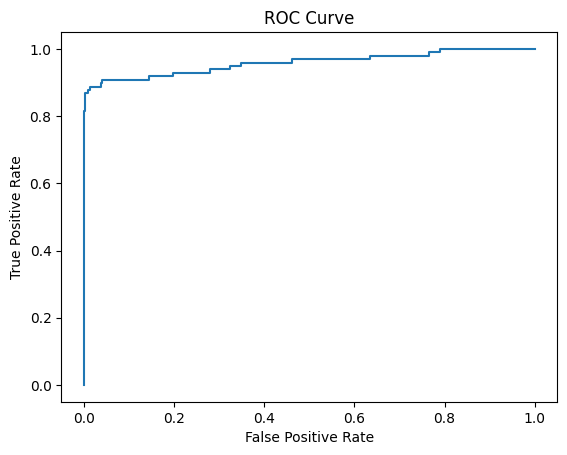

AUC: 0.9584574509319765


In [58]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

print('AUC:', roc_auc_score(y_test, y_proba))

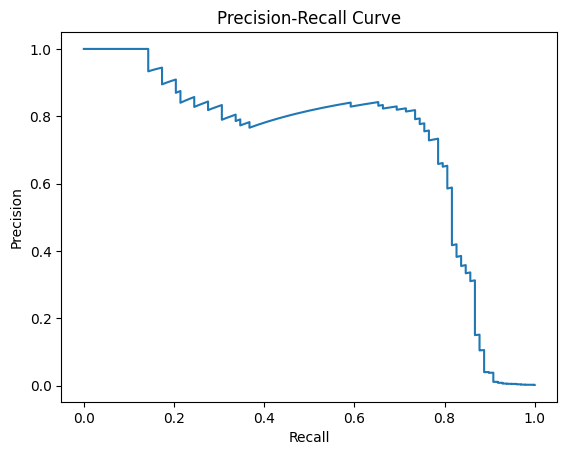

In [59]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

Balanceamento dos dados

Técnicas utilizadas Undersampling reduz a classe majoritária para igualar o tamanho da minoria e Oversampling copia amostras da classe menor até ela ficar do mesmo tamanho da classe maior

In [60]:
#undersampling
fraudes = df[df['Class'] == 1]
normais = df[df['Class'] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [61]:
#Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x, y)


In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight='balanced',
    n_jobs = 1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [63]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("Scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [64]:
threshold = 0.3

y_pred_custom = (y_proba > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.74      0.76        98

    accuracy                           1.00     56962
   macro avg       0.89      0.87      0.88     56962
weighted avg       1.00      1.00      1.00     56962



Modelo avançado - XGBoost

XGBoost é um dos algoritmos mais usados em competiçoes e no mercado

Ele é mais poderoso do que o Random Forest para muitos problemas

In [65]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10, #ajuda com o desbalanceamento
    user_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:06:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "user_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [66]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.81      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



Importancia das variaveis

Ajudam a entender quais variaveis influenciam no modelo possibilita que o analista selecione variaveis com maior relevancia e refaça o processo de treino em busca de uma melhor relação entre as variaveis.

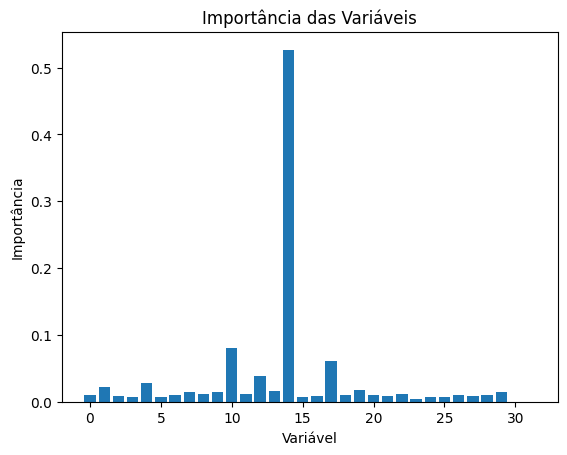

In [67]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title('Importância das Variáveis')
plt.xlabel('Variável')
plt.ylabel('Importância')
plt.show()

Ajuste de hiperparametros

Testamos varias combinações para melhorar o modelo

In [68]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
                  param_grid,
                  scoring = "recall",
                  cv=3
)

grid.fit(x_train, y_train)

print("Melhor modelo", grid.best_params_)

Melhor modelo {'max_depth': 5, 'n_estimators': 100}


Explicabilidade (SHAP)

SHAP mostra como cada variavel influencia a decisão do modelo

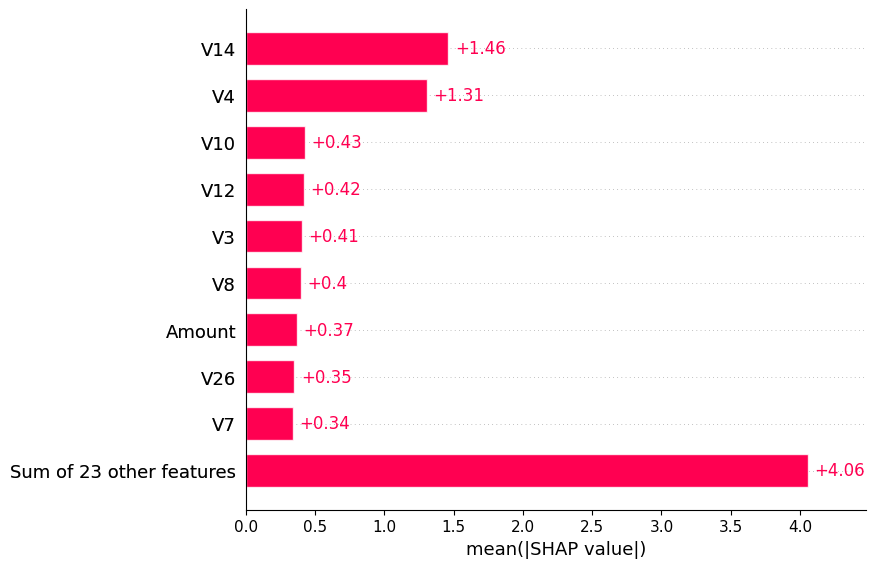

In [71]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)